# Sources and Citations

sklearn dataset: https://scikit-learn.org/0.19/datasets/twenty_newsgroups.html


doc2vec implementation:https://www.geeksforgeeks.org/nlp/doc2vec-in-nlp/

# Import Necessary Libraries and Tools

In [2]:
# installs
!pip install gensim nltk
!pip install yake

# imports
from sklearn.datasets import fetch_20newsgroups
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from nltk.tokenize import word_tokenize

import numpy as np
import umap
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.4/91.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.4/360.4 kB 14.0 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


# Data Retrieval
Import and filter the 20 newsgroup data from sklearn.datasets

pass a specific list of categories (like space, politics, and sports)

use remove=('headers', 'footers', 'quotes') to automatically strip out messy metadata



In [3]:
# data import
# importing sample categories from train data
sample_categories = ['soc.religion.christian', 'sci.space', 'sci.med', 'sci.electronics', 'rec.sport.baseball']
# only doing one category for now to ensure that the clusters make sense
ng_train = fetch_20newsgroups(subset='train',
                              categories=sample_categories[:3],
                              remove=('headers', 'footers', 'quotes'),
                              random_state=42
                              )

list(ng_train.target_names)

['sci.med', 'sci.space', 'soc.religion.christian']

In [4]:

med_count = 0
space_count = 0
chris_count = 0

for doc in ng_train.target:
    match doc:
        case 0:
            med_count += 1
        case 1:
            space_count += 1
        case 2:
            chris_count += 1

print(f'Med: {med_count}\nSpace: {space_count}\nChristian: {chris_count}')

Med: 594
Space: 593
Christian: 599


# Perform Data Preprocessing

lowercase sklearn text and strip out most basic punctuation so that doc2vec doesn't get confused by periods and commas

Honestly might not do this for now. will determine if necessary later

In [5]:
# data preprocessing
# basic cleaning of document text and removal of basic punctuation
punctuation = '\n.,;/\\()?-!'

for p in punctuation:
    for i in range(len(ng_train.data)):
        ng_train.data[i] = ng_train.data[i].replace(p, '')
        ng_train.data[i] = ng_train.data[i].lower()

ng_train.filenames.shape
print(len(ng_train.data))
print(ng_train.data)

1786
["ann jackson ajackson@csubcca wrote on 5 may:i would like to submit the following which helped me enormouslyif it has already been posted i apologizeit seems that during the middle ages it was customary for pastors to explain the trinity to their parishoners by analogy to waterwater is water but can exist in three formsliquid ice and vaporthus it is possible for one essence to exist in three formsand recently the pastor of my church drew an analogy which ialso found usefula woman is often percieved by others in threeways depending on their relationship to hera mother a wife andan employee in a businessthus it seems clear to me that the essence of god can subsist inthe father son and holy spirit or depending on one's particularneed for him", 'i don\'t know if this is the sort of thing you guys liketo discuss  i guess it falls into the area of apologeticsthis is a question that seems to pop up now and again inconversations with nonchristians  it usually appears inthe following sort

# Isolate Sample Category
filter dataset to one category
this will be the playground where you build and tune your embedding, clustering, and extraction models without getting overwhelmed by too much data

In [4]:
# isolate sample

# Generate embeddings with doc2vec

feed single-category text into doc2vec
model will learn the semantic meaning behind the 20 newsgorup vocabulary and convert the articles into dense vector arrays

will first do a small scale practice to ensure that i understand the steps before involving complex data

In [6]:
# source: https://medium.com/@mehdirt/mastering-text-clustering-with-python-a-comprehensive-guide-f8617f53c327#evaluation-and-comparison
from sklearn.decomposition import PCA

def plot_clusters(data, labels, title):
    plt.figure(figsize=(5,3))
    plt.scatter(data[:,0], data[:,1], c=labels, cmap='viridis', s=5)
    plt.title(title)
    plt.colorbar()
    plt.show()

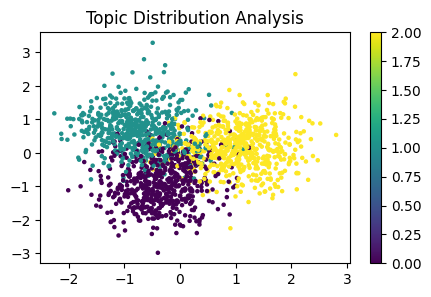

In [13]:
from numpy._core.fromnumeric import cumulative_prod
# embeddings
tagged_ng_train  = [
    TaggedDocument(
        words = word_tokenize(doc.lower()),
        tags=[str(i)]
    )
    for i, doc in enumerate(ng_train.data)
]

# print(len(tagged_ng_train)) should be the same as len of data

# source: https://radimrehurek.com/gensim_3.8.3/models/doc2vec.html


d2v_model = Doc2Vec(
    vector_size=100,
    #min_count=5, default is 5
    epochs=50,
    alpha=0.05,
    dm=0 # distributed memory; remembers context topic
)

d2v_model.build_vocab(tagged_ng_train)
d2v_model.train(
    tagged_ng_train,
    total_examples=d2v_model.corpus_count,
    epochs=d2v_model.epochs
)

embeddings = [
    d2v_model.infer_vector(word_tokenize(doc.lower()))
    for doc in ng_train.data
]

'''for i in range(10):
    if i+1 == len(ng_train.data):
        break
    cumulative_diff = np.mean(np.absolute(np.subtract(embeddings[i], embeddings[i+1])))
    print(f'Vector Difference between Articles {i} and {i+1}: {cumulative_diff:.6f}')
    print(f'Topics: {sample_categories[ng_train.target[i]]} and {sample_categories[ng_train.target[i+1]]}')
    print()'''

data_pca = PCA(n_components=2).fit_transform(embeddings)
plot_clusters(data_pca, ng_train.target, f'Topic Distribution Analysis')


# Cluster with DBSCAN
feed doc2vec embeddings into DBSCAN
adjust eps and min_samples parameters until the groupings make sense

In [14]:
import umap
def reduce_dimension(n_neighbors=5, min_dist=0.1, embeddings=embeddings):
    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=2,
        metric='cosine',
        random_state=42
    )
    return reducer.fit_transform(embeddings)


In [15]:
def run_dbscan(embeddings, eps, min_samples):
    dbs = DBSCAN(eps=eps, min_samples=min_samples, metric='cosine')
    clusters = dbs.fit(embeddings)
    labels = dbs.labels_

    return dbs, clusters, labels

In [16]:
#finetuning
def finetune_dbscan(embeddings):
    eps = 10
    #min_noise = 2**20
    #max_clusters = 0
    max_sc = 0

    best_eps = 0.5
    best_ms = 5

    for ms in range(1,10):
        while eps > 0:
            dbscan, clusters, labels = run_dbscan(embeddings, eps, ms)
            n_clusters_found = len(set(labels)) - (1 if -1 in labels else 0)
            if (n_clusters_found <= 1) or ( n_clusters_found >= len(ng_train.data)):
                eps -= 0.05
                continue
            n_noise = list(labels).count(-1)
            sc = silhouette_score(embeddings, labels)
            if sc > max_sc:
                best_eps = eps
                best_ms = ms
                max_sc = sc

            eps -= 0.05

    return best_eps, best_ms



Clusters found: 1711
Noise docs: 0
Silhouette score: 0.016994
DB score: 0.511076


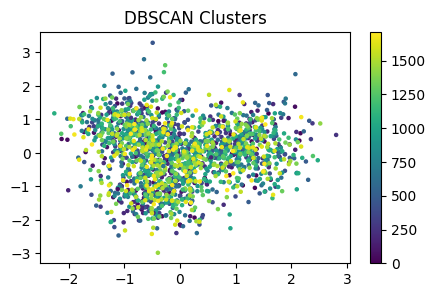

In [17]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

epsilon, min_samples = finetune_dbscan(embeddings)
dbscan, clusters, labels = run_dbscan(embeddings, epsilon, min_samples)
#dbscan_labels = dbscan.fit_predict(doc_vectors)

n_clusters_found = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

# measures how similar a data point is to its own cluster compared to other clusters
# a score near 1 denotes the best meaning that the data point is very compact within its cluster
# the worst value is -1 and near 0 denotes overlapping clusters
score = silhouette_score(embeddings, labels)

# considers intra-cluster compactness and inter-cluster separation
db_score = davies_bouldin_score(embeddings, labels)


print(f'Clusters found: {n_clusters_found}')
print(f'Noise docs: {n_noise}')
print(f'Silhouette score: {score:.6f}')
print(f'DB score: {db_score:.6f}')

data_pca = PCA(n_components=2).fit_transform(embeddings)
plot_clusters(data_pca, labels, 'DBSCAN Clusters')

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


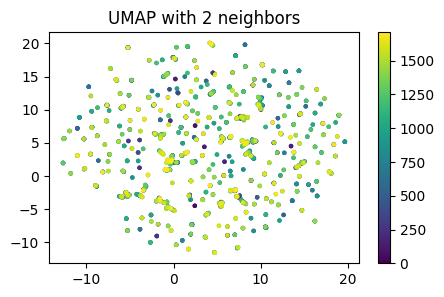

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


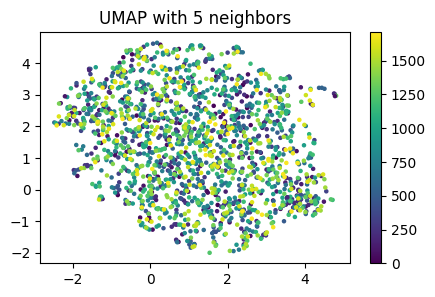

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


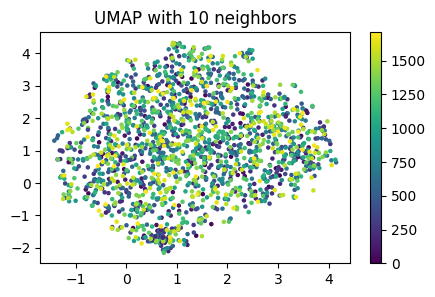

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


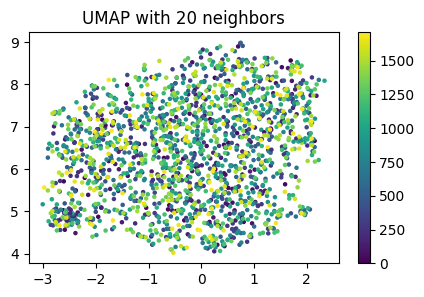

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


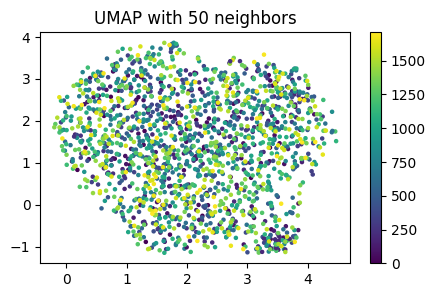

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


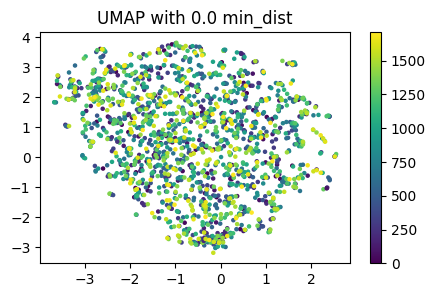

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


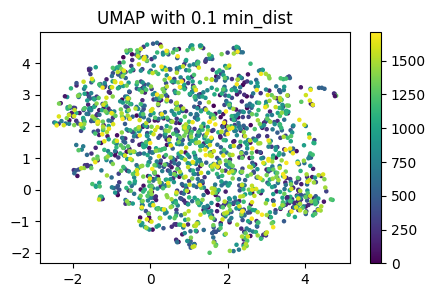

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


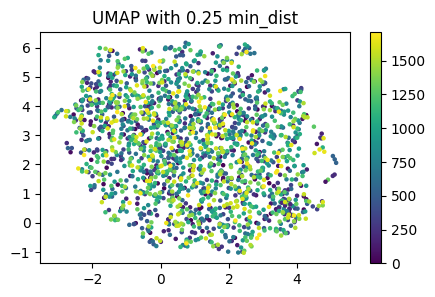

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


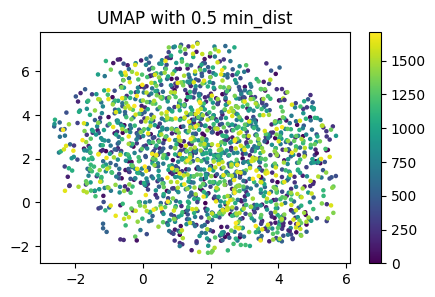

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


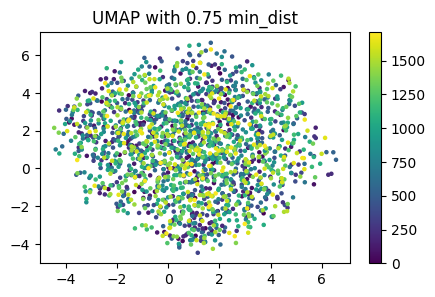

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


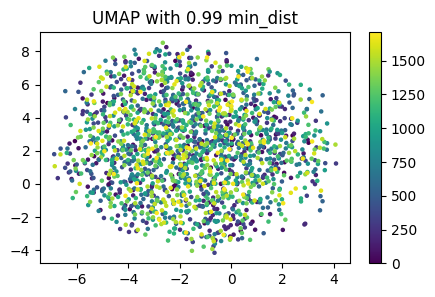

In [18]:
# dbscan with umap
for n in (2, 5, 10, 20, 50):

    reduced_embeddings = reduce_dimension(n_neighbors=n, embeddings=embeddings)
    plot_clusters(reduced_embeddings, labels, f'UMAP with {n} neighbors')

for d in (0.0, 0.1, 0.25, 0.5, 0.75, 0.99):
     reduced_embeddings = reduce_dimension(min_dist=d, embeddings=embeddings)
     plot_clusters(reduced_embeddings, labels, f'UMAP with {d} min_dist')


# Extract keywords with YAKE!

run YAKE! over each of clusters and on a few individual articles
should start seeing major themes pop out as distinct keywords, proving that the pipeline successfully grouped similar stories together

In [19]:
# keyword extraction
# source: https://medium.com/@linz07m/yake-simple-and-smart-keyword-extraction-16089f235d64
import yake
text = ''
keywords = []

keyword_extractor = yake.KeywordExtractor()
for doc in ng_train.data:
    text += doc

keywords = keyword_extractor.extract_keywords(text)



for kw, score in keywords:
    print(f'{kw}:{score}')



space shuttle program:1.7185363915431895e-08
space science data:1.8971635495276267e-08
space flight center:2.3967196568556124e-08
national space science:2.7716183201804822e-08
space launch system:4.5785077564059936e-08
lord jesus christ:5.149626883375215e-08
medical newsletter page:5.5153644829800205e-08
space shuttle launch:5.934011311943832e-08
national space society:6.200550582485332e-08
space called space:6.460821531811088e-08
space science missions:7.082750753754089e-08
science data center:7.710168814202594e-08
data center space:7.930141019856597e-08
space activities space:8.617326977512817e-08
space systems division:8.663613426893132e-08
life good people:9.127284788802512e-08
space telescope science:9.355722302471737e-08
god law jesus:9.487835004156828e-08
lunar power system:9.596945359950802e-08
space shuttle mission:9.93335152960168e-08


# Score Sentiment and Bias with RNNs
pass the clustered texts into RNN architecture

In [20]:
# sentiment scoring

# Scale, Test, and Swap
once this entire flow works well for first category, run the remaining four categories through it to ensure it scales

when teammate is done with their part, just swap out the 20 newsgroup function for her data feed and your ml architecture should be ready to go

In [21]:
# scaling and testing